# Импорт библиотек

In [61]:
import pandas as pd
import numpy as np
import plotly.express as px

# Анализ данных

**Цель: прогнозировать продажи семейств товаров, продаваемых в магазинах. 
Всего 54 магазина, и моя идея состоит в том, чтобы обучить модель на данных каждого магазина отдельно.**

## Train and test datasets

In [ ]:
train = pd.read_csv('train.csv', dtype={'store_nbr': 'category'}, 
                    usecols=['store_nbr', 'family', 'date', 'sales', 'onpromotion'])
test = pd.read_csv('test.csv', dtype={'store_nbr': 'category'},
                   usecols=['store_nbr', 'family', 'date', 'onpromotion'])

# Проверка на пустые значения
print('Missing values in train:', train.isna().sum().sum())
print('Missing values in test:', test.isna().sum().sum())

train['date'] = pd.to_datetime(train['date'])
test['date'] = pd.to_datetime(test['date'])

Missing values in train: 0
Missing values in test: 0


In [63]:
train.head(20)

,date,store_nbr,family,sales,onpromotion
0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,2013-01-01,1,BABY CARE,0.0,0
2,2013-01-01,1,BEAUTY,0.0,0
3,2013-01-01,1,BEVERAGES,0.0,0
4,2013-01-01,1,BOOKS,0.0,0
5,2013-01-01,1,BREAD/BAKERY,0.0,0
6,2013-01-01,1,CELEBRATION,0.0,0
7,2013-01-01,1,CLEANING,0.0,0
8,2013-01-01,1,DAIRY,0.0,0
9,2013-01-01,1,DELI,0.0,0


**Много нулей, это может означать, что магазин еще не работал, или у нас просто нет информации о нем.**

In [64]:
temp = train.set_index('date').groupby('store_nbr').resample('D').sales.sum().reset_index()
px.line(temp, x='date', y='sales', color='store_nbr',
        title='Daily total sales of the stores')

**В некоторых магазинах нет информации о продажах до 2014, 2015 или 2017 годов. 
Надо это исправить.**

In [65]:
print(train.shape)
train = train[~((train.store_nbr == '52') & (train.date < "2017-04-20"))]
train = train[~((train.store_nbr == '22') & (train.date < "2015-10-09"))]
train = train[~((train.store_nbr == '42') & (train.date < "2015-08-21"))]
train = train[~((train.store_nbr == '21') & (train.date < "2015-07-24"))]
train = train[~((train.store_nbr == '29') & (train.date < "2015-03-20"))]
train = train[~((train.store_nbr == '20') & (train.date < "2015-02-13"))]
train = train[~((train.store_nbr == '53') & (train.date < "2014-05-29"))]
train = train[~((train.store_nbr == '36') & (train.date < "2013-05-09"))]
print(train.shape)

(3000888, 5)
(2780316, 5)


**В нашей обучающей и тестовой выборке есть столбец onpromotion, который означает общее количество позиций в семействе продуктов, которые рекламировались на определенную дату. Это должно положительно сказаться на продажах.**

## Transactions

In [66]:
transactions = pd.read_csv('transactions.csv', dtype={'store_nbr': 'category'})
transactions.head()

,date,store_nbr,transactions
0,2013-01-01,25,770
1,2013-01-02,1,2111
2,2013-01-02,2,2358
3,2013-01-02,3,3487
4,2013-01-02,4,1922


In [ ]:
print('Missing values in transactions:', train.isna().sum().sum())


transactions['date'] = pd.to_datetime(transactions['date'])

# Доказательство того, что транзакции тесно связаны с продажами
temp = pd.merge(train.groupby(['date', 'store_nbr']).sales.sum().reset_index(),
                transactions, how='left')
print(temp.corr("spearman").sales.loc["transactions"])

# Магазины в праздничные дни зарабатывают больше денег, чем в рабочие дни
temp = transactions.copy()
temp['year'] = temp.date.dt.year
temp['day_of_week'] = temp.date.dt.dayofweek + 1
temp = temp.groupby(['year', 'day_of_week']).transactions.mean().reset_index()

px.line(temp, x='day_of_week', y='transactions', color='year', title='Transactions')

Missing values in transactions: 0
0.8174644354591597


**Из визуализаци понятно, что мы должны правильно установить выходные дни, чтобы получить лучшие результаты**

## Holidays Events

In [68]:
def strip_spaces(a_str_with_spaces):
    return a_str_with_spaces.replace(' ', '')

holidays = pd.read_csv('holidays_events.csv', index_col='date',
                       parse_dates=['date'],
                       converters={'locale_name': strip_spaces})

holidays.head()

,type,locale,locale_name,description,transferred
date,,,,,
2012-03-02,Holiday,Local,Manta,Fundacion de Manta,False
2012-04-01,Holiday,Regional,Cotopaxi,Provincializacion de Cotopaxi,False
2012-04-12,Holiday,Local,Cuenca,Fundacion de Cuenca,False
2012-04-14,Holiday,Local,Libertad,Cantonizacion de Libertad,False
2012-04-21,Holiday,Local,Riobamba,Cantonizacion de Riobamba,False


In [69]:
print('Holidays types:', holidays['type'].unique())
print('Holidays region types:', holidays['locale'].unique()) 
print('Holidays locale names:', holidays['locale_name'].unique())  

Holidays types: ['Holiday' 'Transfer' 'Additional' 'Bridge' 'Work Day' 'Event']
Holidays region types: ['Local' 'Regional' 'National']
Holidays locale names: ['Manta' 'Cotopaxi' 'Cuenca' 'Libertad' 'Riobamba' 'Puyo' 'Guaranda'
 'Imbabura' 'Latacunga' 'Machala' 'SantoDomingo' 'ElCarmen' 'Cayambe'
 'Esmeraldas' 'Ecuador' 'Ambato' 'Ibarra' 'Quevedo'
 'SantoDomingodelosTsachilas' 'SantaElena' 'Quito' 'Loja' 'Salinas'
 'Guayaquil']


In [ ]:
holidays.isna().sum()  

type           0
locale         0
locale_name    0
description    0
transferred    0
dtype: int64

**Теперь: нам нужно создать полный календарь и указать рабочие и нерабочие дни.**

In [ ]:
# Календарь
holidays_rdy = pd.DataFrame(index=pd.date_range('2013-01-01', '2017-08-31'))
holidays_rdy['day_of_week'] = holidays_rdy.index.dayofweek + 1  # Понедельник - 1, Воскресенье - 7
holidays_rdy['work_day'] = True
holidays_rdy.loc[holidays_rdy['day_of_week'] > 5, 'work_day'] = False  # False для субботы и воскресенья

# Исправление дубликатов индексов в данных о праздниках
duplicates = holidays[holidays.index.duplicated(keep=False)]
print(duplicates['locale_name'])

duplicates = [('2012-06-25', 'Latacunga Machala'), ('2012-07-03', 'ElCarmen'),
              ('2012-12-22', 'Ecuador'), ('2012-12-24', 'Ecuador'),
              ('2012-12-31', 'Ecuador'), ('2013-05-12', 'Ecuador'),
              ('2013-06-25', 'Machala Latacunga'), ('2013-07-03', 'SantoDomingo'),
              ('2013-12-22', 'Salinas'), ('2014-06-25', 'Machala Imbabura Ecuador'),
              ('2014-07-03', 'SantoDomingo'), ('2014-12-22', 'Ecuador'),
              ('2014-12-26', 'Ecuador'), ('2015-06-25', 'Imbabura Latacunga'),
              ('2015-07-03', 'SantoDomingo'), ('2015-12-22', 'Salinas'),
              ('2016-04-21', 'Ecuador'), ('2016-05-01', 'Ecuador'),
              ('2016-05-07', 'Ecuador'), ('2016-05-08', 'Ecuador'),
              ('2016-05-12', 'Ecuador'), ('2016-06-25', 'Imbabura Latacunga'),
              ('2016-07-03', 'SantoDomingo'), ('2016-07-24', 'Guayaquil'),
              ('2016-11-12', 'Ecuador'), ('2016-12-22', 'Salinas'),
              ('2017-04-14', 'Ecuador'), ('2017-06-25', 'Latacunga Machala'),
              ('2017-07-03', 'SantoDomingo'), ('2017-12-08', 'Quito'),
              ('2017-12-22', 'Ecuador')]

holidays = holidays.groupby(holidays.index).first()
for date, locale_name in duplicates:
    holidays.loc[date, 'locale_name'] = holidays.loc[date, 'locale_name'] + ' ' + locale_name

date
2012-06-25        Imbabura
2012-06-25       Latacunga
2012-06-25         Machala
2012-07-03    SantoDomingo
2012-07-03        ElCarmen
                  ...     
2017-07-03    SantoDomingo
2017-12-08            Loja
2017-12-08           Quito
2017-12-22         Salinas
2017-12-22         Ecuador
Name: locale_name, Length: 69, dtype: object


In [ ]:
# Применяем выходные к календарю
holidays_rdy = holidays_rdy.merge(holidays, how='left', left_index=True, right_index=True)

holidays_rdy.loc[holidays_rdy['type'] == 'Work Day', 'work_day'] = True

holidays_rdy.loc[(holidays_rdy['type'] == 'Holiday') &
                 (holidays_rdy['locale_name'].str.contains('Ecuador', na=False)),
                 'work_day'] = False
holidays_rdy.loc[(holidays_rdy['type'] == 'Transfer') & 
                 (holidays_rdy['locale_name'].str.contains('Ecuador', na=False)),  
                 'work_day'] = False
holidays_rdy.loc[(holidays_rdy['type'] == 'Additional') & 
                 (holidays_rdy['locale_name'].str.contains('Ecuador', na=False)),
                 'work_day'] = False
holidays_rdy.loc[(holidays_rdy['type'] == 'Bridge') & 
                 (holidays_rdy['locale_name'].str.contains('Ecuador', na=False)),   
                 'work_day'] = False

holidays_rdy.drop(['locale'], axis=1, inplace=True)

holidays_rdy.loc[holidays_rdy['transferred'] == True, 'work_day'] = True

In [73]:
holidays_rdy

,day_of_week,work_day,type,locale_name,description,transferred
2013-01-01,2,False,Holiday,Ecuador,Primer dia del ano,False
2013-01-02,3,True,NaN,NaN,NaN,NaN
2013-01-03,4,True,NaN,NaN,NaN,NaN
2013-01-04,5,True,NaN,NaN,NaN,NaN
2013-01-05,6,True,Work Day,Ecuador,Recupero puente Navidad,False
...,...,...,...,...,...,...
2017-08-27,7,False,NaN,NaN,NaN,NaN
2017-08-28,1,True,NaN,NaN,NaN,NaN
2017-08-29,2,True,NaN,NaN,NaN,NaN
2017-08-30,3,True,NaN,NaN,NaN,NaN


**Столбец: "Событие"  
В наборе данных есть несколько событий: День матери, Чемпионат по футболу, Черная пятница, Киберпонедельник, Землетрясение в Манаби.
Мы должны понимать, как это влияет на продажи.**

In [74]:
events = holidays_rdy[holidays_rdy['type']=='Event']
events

,day_of_week,work_day,type,locale_name,description,transferred
2014-05-11,7,False,Event,Ecuador,Dia de la Madre,False
2014-06-12,4,True,Event,Ecuador,Inauguracion Mundial de futbol Brasil,False
2014-06-15,7,False,Event,Ecuador,Mundial de futbol Brasil: Ecuador-Suiza,False
2014-06-20,5,True,Event,Ecuador,Mundial de futbol Brasil: Ecuador-Honduras,False
2014-06-28,6,False,Event,Ecuador,Mundial de futbol Brasil: Octavos de Final,False
2014-06-29,7,False,Event,Ecuador,Mundial de futbol Brasil: Octavos de Final,False
2014-06-30,1,True,Event,Ecuador,Mundial de futbol Brasil: Octavos de Final,False
2014-07-01,2,True,Event,Ecuador,Mundial de futbol Brasil: Octavos de Final,False
2014-07-04,5,True,Event,Ecuador,Mundial de futbol Brasil: Cuartos de Final,False
2014-07-05,6,False,Event,Ecuador,Mundial de futbol Brasil: Cuartos de Final,False


**Мы должны установить единое обозначение для всех футбольных событий, а также для землетрясений**

**Проверка средних между обычными и праздничными днями**

In [75]:
holidays_rdy.loc[holidays_rdy['description'].str.contains('Terremoto', na=False),
                 'description'] = 'Earthquake'
holidays_rdy.loc[holidays_rdy['description'].str.contains('futbol', na=False), 
                 'description'] = 'Football'
events = holidays_rdy[holidays_rdy['type']=='Event']

print(events['description'].unique())
 
sales = train.groupby(['date']).sales.sum()
events = events.merge(sales, how='left', left_index=True, right_index=True)
print(events.groupby(['description']).sales.mean())
print('All sales mean:', sales.mean())

['Dia de la Madre' 'Football' 'Black Friday' 'Cyber Monday' 'Earthquake']
description
Black Friday       647508.781658
Cyber Monday       777344.484674
Dia de la Madre    632258.371941
Earthquake         866433.436092
Football           569432.001918
Name: sales, dtype: float64
All sales mean: 637556.3849186868


**Продажи не сильно зависят от футбола и дня матери**

In [76]:
descriptions = pd.get_dummies(holidays_rdy['description'])[['Earthquake', 'Cyber Monday', 'Black Friday']]
holidays_rdy = holidays_rdy.merge(descriptions, how='left', left_index=True, right_index=True)

holidays_rdy['locale_name'].fillna('Ecuador', inplace=True)

holidays_rdy.drop(['type', 'description', 'transferred'], axis=1, inplace=True)

In [77]:
holidays_rdy['date'] = holidays_rdy.index
holidays_rdy['date'] = pd.to_datetime(holidays_rdy['date'])
holidays_rdy['date'] = holidays_rdy['date'].dt.to_period('D')
holidays_rdy = holidays_rdy.set_index(['date'])

holidays_rdy = pd.get_dummies(holidays_rdy, columns=['day_of_week'])

In [78]:
holidays_rdy.columns

Index(['work_day', 'locale_name', 'Earthquake', 'Cyber Monday', 'Black Friday',
       'day_of_week_1', 'day_of_week_2', 'day_of_week_3', 'day_of_week_4',
       'day_of_week_5', 'day_of_week_6', 'day_of_week_7'],
      dtype='object')

## Oil

In [79]:
oil = pd.read_csv('oil.csv')
oil['date'] = pd.to_datetime(oil['date'])
oil.head()

,date,dcoilwtico
0,2013-01-01,NaN
1,2013-01-02,93.14
2,2013-01-03,92.97
3,2013-01-04,93.12
4,2013-01-07,93.20


In [80]:
oil = oil.set_index('date')['dcoilwtico'].resample('D').sum().reset_index() 

oil['dcoilwtico'] = np.where(oil['dcoilwtico']==0, np.nan, oil['dcoilwtico'])
oil['dcoilwtico_interpolated'] = oil.dcoilwtico.interpolate()

oil.head(10)

,date,dcoilwtico,dcoilwtico_interpolated
0,2013-01-01,NaN,NaN
1,2013-01-02,93.14,93.140000
2,2013-01-03,92.97,92.970000
3,2013-01-04,93.12,93.120000
4,2013-01-05,NaN,93.146667
5,2013-01-06,NaN,93.173333
6,2013-01-07,93.20,93.200000
7,2013-01-08,93.21,93.210000
8,2013-01-09,93.08,93.080000
9,2013-01-10,93.81,93.810000


In [81]:
temp = oil.melt(id_vars=['date'], var_name='Legend') 
px.line(temp.sort_values(['Legend', 'date'], ascending=[False, True]), x='date',
        y='value', color='Legend', title='Daily Oil Price')

In [82]:
oil_rdy = oil.loc[:, ['date', 'dcoilwtico_interpolated']]
oil_rdy.iloc[0, 1] = 93.1

assert oil_rdy.isna().sum().sum() == 0

oil_rdy['date'] = pd.to_datetime(oil_rdy['date'])
oil_rdy['date'] = oil_rdy['date'].dt.to_period('D')
oil_rdy = oil_rdy.set_index(['date'])
oil_rdy

,dcoilwtico_interpolated
date,
2013-01-01,93.100000
2013-01-02,93.140000
2013-01-03,92.970000
2013-01-04,93.120000
2013-01-05,93.146667
...,...
2017-08-27,46.816667
2017-08-28,46.400000
2017-08-29,46.460000


**Влияют ли цены на нефть на продажи?**

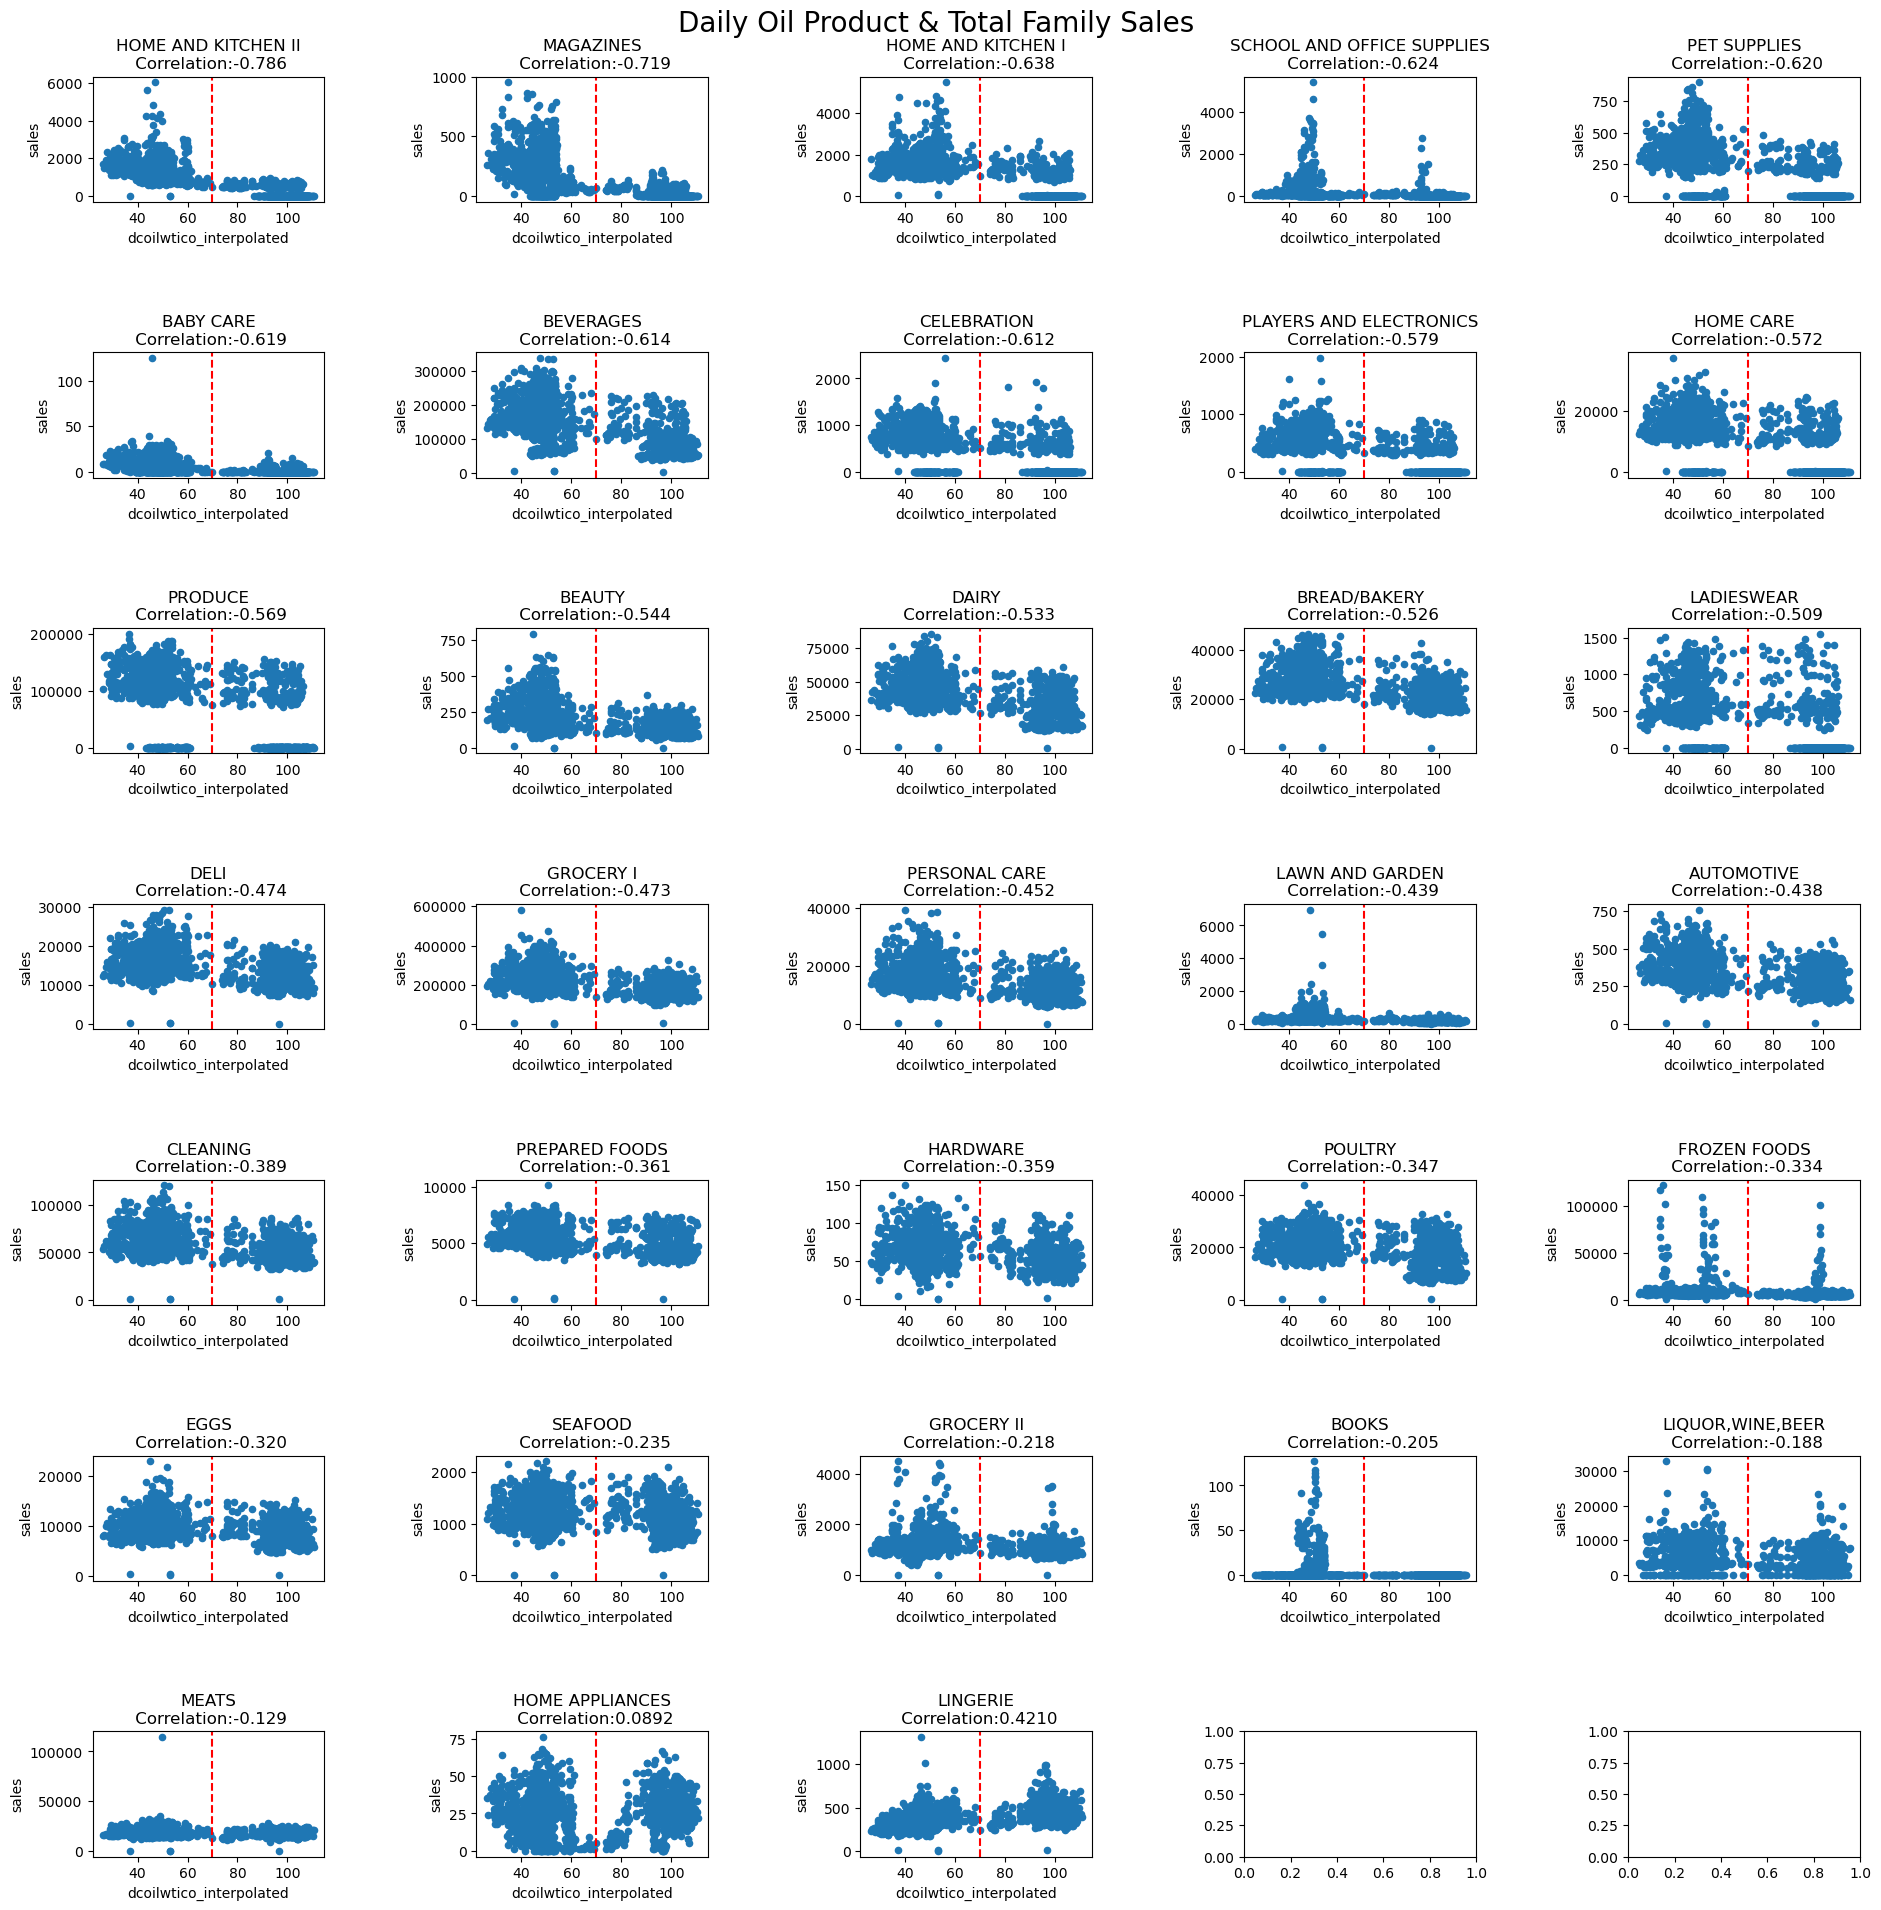

In [83]:
import matplotlib.pyplot as plt

def plot_sales_and_oil_dependency():
    a = pd.merge(train.groupby(["date", "family"]).sales.sum().reset_index(),
                 oil.drop("dcoilwtico", axis=1), how="left")
    c = a.groupby("family").corr("spearman").reset_index()
    c = c[c.level_1 == "dcoilwtico_interpolated"][["family", "sales"]].sort_values("sales")
    
    fig, axes = plt.subplots(7, 5, figsize=(20, 20))
    for i, fam in enumerate(c.family):
        a[a.family == fam].plot.scatter(x="dcoilwtico_interpolated", y="sales", ax=axes[i // 5, i % 5])
        axes[i // 5, i % 5].set_title(fam + "\n Correlation:" + str(c[c.family == fam].sales.iloc[0])[:6],
                                 fontsize=12)
        axes[i // 5, i % 5].axvline(x=70, color='r', linestyle='--')

    plt.tight_layout(pad=5)
    plt.suptitle("Daily Oil Product & Total Family Sales \n", fontsize=20)
    plt.show()

plot_sales_and_oil_dependency()

In [84]:
oil_rdy['rolling_mean_7'] = oil_rdy['dcoilwtico_interpolated'].rolling(7).mean()
oil_rdy.fillna(93.1, inplace=True)
oil_rdy

,dcoilwtico_interpolated,rolling_mean_7
date,,
2013-01-01,93.100000,93.100000
2013-01-02,93.140000,93.100000
2013-01-03,92.970000,93.100000
2013-01-04,93.120000,93.100000
2013-01-05,93.146667,93.100000
...,...,...
2017-08-27,46.816667,47.490000
2017-08-28,46.400000,47.348571
2017-08-29,46.460000,47.178571


## Stores

In [85]:
stores = pd.read_csv('stores.csv', index_col='store_nbr',
                     converters={'city': strip_spaces, 'state': strip_spaces})

stores.head()

,city,state,type,cluster
store_nbr,,,,
1,Quito,Pichincha,D,13
2,Quito,Pichincha,D,13
3,Quito,Pichincha,D,8
4,Quito,Pichincha,D,9
5,SantoDomingo,SantoDomingodelosTsachilas,D,4


In [ ]:
# Уникальные значения
print('Cities:\n', stores['city'].unique())  
print('States:\n', stores['state'].unique())  
print('Store types:\n', stores['type'].unique())
print('Clusters:\n', sorted(list(stores['cluster'].unique())))

# Пустые значения
print('Missing values:', stores.isna().sum().sum())

Cities:
 ['Quito' 'SantoDomingo' 'Cayambe' 'Latacunga' 'Riobamba' 'Ibarra'
 'Guaranda' 'Puyo' 'Ambato' 'Guayaquil' 'Salinas' 'Daule' 'Babahoyo'
 'Quevedo' 'Playas' 'Libertad' 'Cuenca' 'Loja' 'Machala' 'Esmeraldas'
 'Manta' 'ElCarmen']
States:
 ['Pichincha' 'SantoDomingodelosTsachilas' 'Cotopaxi' 'Chimborazo'
 'Imbabura' 'Bolivar' 'Pastaza' 'Tungurahua' 'Guayas' 'SantaElena'
 'LosRios' 'Azuay' 'Loja' 'ElOro' 'Esmeraldas' 'Manabi']
Store types:
 ['D' 'B' 'C' 'E' 'A']
Clusters:
 [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17]
Missing values: 0


**Мы должны связать магазины и праздники по местоположению, потому что праздники могут быть местными или региональными (в одном городе или во всем штате).**

In [87]:
stores_rdy = stores.loc[:, ['city', 'state']]
stores_rdy.head()

,city,state
store_nbr,,
1,Quito,Pichincha
2,Quito,Pichincha
3,Quito,Pichincha
4,Quito,Pichincha
5,SantoDomingo,SantoDomingodelosTsachilas


# Preprocessing

**Я хочу разделить наборы данных для обучения и тестирования, чтобы обучать модели для каждого магазина отдельно из-за местных праздников.**

## 1

In [88]:
train['date'] = train['date'].dt.to_period('D')
train_rdy = train.set_index(['store_nbr', 'family', 'date']).sort_index()
display(train_rdy)

test['date'] = test['date'].dt.to_period('D')
test_rdy = test.set_index(['store_nbr', 'family', 'date']).sort_index()
display(test_rdy)

sales  onpromotion
store_nbr family     date                              
1         AUTOMOTIVE 2013-01-01   0.000000            0
                     2013-01-02   2.000000            0
                     2013-01-03   3.000000            0
                     2013-01-04   3.000000            0
                     2013-01-05   5.000000            0
...                                    ...          ...
9         SEAFOOD    2017-08-11  23.831000            0
                     2017-08-12  16.859001            4
                     2017-08-13  20.000000            0
                     2017-08-14  17.000000            0
                     2017-08-15  16.000000            0

[2780316 rows x 2 columns]

onpromotion
store_nbr family     date                   
1         AUTOMOTIVE 2017-08-16            0
                     2017-08-17            0
                     2017-08-18            0
                     2017-08-19            0
                     2017-08-20            0
...                                      ...
9         SEAFOOD    2017-08-27            0
                     2017-08-28            0
                     2017-08-29            0
                     2017-08-30            0
                     2017-08-31            0

[28512 rows x 1 columns]

In [89]:
sdate = '2015-03-25'
edate = '2017-08-15'

y_arr = []
onpromotion_arr = []
test_onpromotion_arr = []

for nbr in stores.index:

    temp = train_rdy.loc[str(nbr), 'sales']
    y_arr.append(temp.unstack(['family']).loc[sdate:edate])
    

    onpromotion = train_rdy.loc[str(nbr), 'onpromotion']
    onpromotion = onpromotion.unstack(['family']).loc[sdate:edate].sum(axis=1)
    onpromotion.name = 'onpromotion'
    onpromotion_arr.append(onpromotion)
    

    test_onpromotion = test_rdy.loc[str(nbr), 'onpromotion']
    test_onpromotion = test_onpromotion.unstack(['family']).sum(axis=1)
    test_onpromotion.name = 'onpromotion'
    test_onpromotion_arr.append(test_onpromotion)
    
    
y_arr[33] # второй магазин

family,AUTOMOTIVE,BABY CARE,BEAUTY,BEVERAGES,BOOKS,BREAD/BAKERY,CELEBRATION,CLEANING,DAIRY,DELI,...,MAGAZINES,MEATS,PERSONAL CARE,PET SUPPLIES,PLAYERS AND ELECTRONICS,POULTRY,PREPARED FOODS,PRODUCE,SCHOOL AND OFFICE SUPPLIES,SEAFOOD
date,,,,,,,,,,,,,,,,,,,,,
2015-03-25,0.0,0.0,3.0,1156.0,0.0,676.0,0.0,802.0,407.0,235.519,...,0.0,159.663,180.0,0.0,0.0,106.585000,23.000,0.000,0.0,0.0
2015-03-26,1.0,0.0,1.0,1464.0,0.0,674.0,0.0,795.0,416.0,310.698,...,0.0,145.795,192.0,0.0,0.0,115.128000,27.000,0.000,0.0,5.0
2015-03-27,2.0,0.0,1.0,1895.0,0.0,843.0,0.0,1036.0,560.0,264.065,...,0.0,120.211,251.0,0.0,0.0,95.366000,55.000,0.000,0.0,1.0
2015-03-28,5.0,0.0,5.0,1558.0,0.0,774.0,0.0,1093.0,635.0,296.167,...,0.0,158.577,312.0,0.0,0.0,173.983000,23.000,0.000,0.0,1.0
2015-03-29,3.0,0.0,3.0,1699.0,0.0,617.0,0.0,847.0,554.0,218.756,...,0.0,114.373,250.0,0.0,0.0,150.707000,37.000,0.000,0.0,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2017-08-11,1.0,1.0,0.0,2866.0,0.0,840.0,11.0,802.0,576.0,299.419,...,3.0,174.091,243.0,3.0,3.0,197.791000,40.282,599.000,4.0,0.0
2017-08-12,3.0,1.0,3.0,2343.0,0.0,671.0,12.0,951.0,467.0,171.674,...,2.0,98.216,329.0,1.0,5.0,132.301000,40.741,604.801,4.0,0.0
2017-08-13,4.0,0.0,2.0,2810.0,0.0,677.0,4.0,642.0,675.0,210.663,...,1.0,165.617,239.0,3.0,9.0,159.386000,22.000,634.453,9.0,0.0


## 2

In [ ]:
from statsmodels.tsa.deterministic import CalendarFourier, DeterministicProcess

fourier = CalendarFourier(freq='W', order=4)
X_arr = []
X_test_arr = []
store_index = 1

for y, onpromotion, test_onpromotion in zip(y_arr, onpromotion_arr, test_onpromotion_arr): 
    dp = DeterministicProcess(index=y.index,
                              constant=False,
                              order=1,
                              seasonal=False,
                              additional_terms=[fourier],
                              drop=True)
    X = dp.in_sample()
    X_test = dp.out_of_sample(steps=16)
    
    X = X.merge(onpromotion, how='left', left_index=True, right_index=True)
    X_test = X_test.merge(test_onpromotion, how='left', left_index=True, right_index=True)
    
    X = X.merge(holidays_rdy, how='left', left_index=True, right_index=True)
    X_test = X_test.merge(holidays_rdy, how='left', left_index=True, right_index=True)
    
    store_state = stores.loc[store_index, 'state']
    store_city = stores.loc[store_index, 'city']
    
    for j in X.index: 
        if X.loc[j, 'locale_name'].find(store_state) != -1 or X.loc[j, 'locale_name'].find(store_city) != -1:
            X.loc[j, 'work_day'] = False
    
    for j in X_test.index: 
        if X_test.loc[j, 'locale_name'].find(store_state) != -1 or X_test.loc[j, 'locale_name'].find(store_city) != -1:
            X_test.loc[j, 'work_day'] = False
    
    X.drop(['locale_name'], axis=1, inplace=True)  
    X_test.drop(['locale_name'], axis=1, inplace=True)  
    
    X = X.merge(oil_rdy, how='left', left_index=True, right_index=True)
    X_test = X_test.merge(oil_rdy, how='left', left_index=True, right_index=True)
    
    X_arr.append(X)
    X_test_arr.append(X_test)
    
    store_index += 1
    
X_arr[0].head(10)

,trend,"sin(1,freq=W-SUN)","cos(1,freq=W-SUN)","sin(2,freq=W-SUN)","cos(2,freq=W-SUN)","sin(3,freq=W-SUN)","cos(3,freq=W-SUN)",onpromotion,work_day,Earthquake,...,Black Friday,day_of_week_1,day_of_week_2,day_of_week_3,day_of_week_4,day_of_week_5,day_of_week_6,day_of_week_7,dcoilwtico_interpolated,rolling_mean_7
date,,,,,,,,,,,,,,,,,,,,,
2015-03-25,1.0,0.974928,-0.222521,-0.433884,-0.900969,-0.781831,0.623490,14,True,False,...,False,False,False,True,False,False,False,False,48.750000,46.657143
2015-03-26,2.0,0.433884,-0.900969,-0.781831,0.623490,0.974928,-0.222521,6,True,False,...,False,False,False,False,True,False,False,False,51.410000,47.712857
2015-03-27,3.0,-0.433884,-0.900969,0.781831,0.623490,-0.974928,-0.222521,163,True,False,...,False,False,False,False,False,True,False,False,48.830000,48.117143
2015-03-28,4.0,-0.974928,-0.222521,0.433884,-0.900969,0.781831,0.623490,8,False,False,...,False,False,False,False,False,False,True,False,48.773333,48.446667
2015-03-29,5.0,-0.781831,0.623490,-0.974928,-0.222521,-0.433884,-0.900969,17,False,False,...,False,False,False,False,False,False,False,True,48.716667,48.701429
2015-03-30,6.0,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,19,True,False,...,False,True,False,False,False,False,False,False,48.660000,48.881429
2015-03-31,7.0,0.781831,0.623490,0.974928,-0.222521,0.433884,-0.900969,14,True,False,...,False,False,True,False,False,False,False,False,47.720000,48.980000
2015-04-01,8.0,0.974928,-0.222521,-0.433884,-0.900969,-0.781831,0.623490,24,True,False,...,False,False,False,True,False,False,False,False,50.120000,49.175714
2015-04-02,9.0,0.433884,-0.900969,-0.781831,0.623490,0.974928,-0.222521,11,True,False,...,False,False,False,False,True,False,False,False,49.130000,48.850000


In [107]:
X_arr[21]

,trend,"sin(1,freq=W-SUN)","cos(1,freq=W-SUN)","sin(2,freq=W-SUN)","cos(2,freq=W-SUN)","sin(3,freq=W-SUN)","cos(3,freq=W-SUN)",onpromotion,work_day,Earthquake,...,Black Friday,day_of_week_1,day_of_week_2,day_of_week_3,day_of_week_4,day_of_week_5,day_of_week_6,day_of_week_7,dcoilwtico_interpolated,rolling_mean_7
date,,,,,,,,,,,,,,,,,,,,,
2015-10-09,1.0,-0.433884,-0.900969,0.781831,0.623490,-0.974928,-0.222521,128,False,False,...,False,False,False,False,False,True,False,False,49.670000,47.660000
2015-10-10,2.0,-0.974928,-0.222521,0.433884,-0.900969,0.781831,0.623490,64,False,False,...,False,False,False,False,False,False,True,False,48.810000,48.091905
2015-10-11,3.0,-0.781831,0.623490,-0.974928,-0.222521,-0.433884,-0.900969,83,False,False,...,False,False,False,False,False,False,False,True,47.950000,48.365714
2015-10-12,4.0,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,45,True,False,...,False,True,False,False,False,False,False,False,47.090000,48.481429
2015-10-13,5.0,0.781831,0.623490,0.974928,-0.222521,0.433884,-0.900969,137,True,False,...,False,False,True,False,False,False,False,False,46.700000,48.220000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2017-08-11,671.0,-0.433884,-0.900969,0.781831,0.623490,-0.974928,-0.222521,182,False,False,...,False,False,False,False,False,True,False,False,48.810000,49.188571
2017-08-12,672.0,-0.974928,-0.222521,0.433884,-0.900969,0.781831,0.623490,155,False,False,...,False,False,False,False,False,False,True,False,48.403333,49.031429
2017-08-13,673.0,-0.781831,0.623490,-0.974928,-0.222521,-0.433884,-0.900969,175,False,False,...,False,False,False,False,False,False,False,True,47.996667,48.825714


# Modelling

In [114]:
from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import mean_squared_log_error
from sklearn.model_selection import train_test_split

ridge = make_pipeline(RobustScaler(),
                      Ridge(alpha=31.0))

t_errors = []
v_errors = []

# Ошибка для каждого магазина
for X, y in zip(X_arr, y_arr):
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.3,
                                                      random_state=1, shuffle=False)
    model = ridge.fit(X_train, y_train)
    train_pred = pd.DataFrame(model.predict(X_train), index=X_train.index,
                              columns=y_train.columns).clip(0.0)
    val_pred = pd.DataFrame(model.predict(X_val), index=X_val.index,
                            columns=y_val.columns).clip(0.0)

    y_train = y_train.stack(['family']).reset_index()
    y_train['pred'] = train_pred.stack(['family']).reset_index().loc[:, 0]
    print(y_train)
    y_val = y_val.stack(['family']).reset_index()
    y_val['pred'] = val_pred.stack(['family']).reset_index().loc[:, 0]

    t_errors.append(y_train.groupby('family').apply(
        lambda r: mean_squared_log_error(r.loc[:, 0], r['pred'])))
    v_errors.append(y_val.groupby('family').apply(
        lambda r: mean_squared_log_error(r.loc[:, 0], r['pred'])))

             date                      family         0         pred
0      2015-03-25                  AUTOMOTIVE     0.000     3.600346
1      2015-03-25                   BABY CARE     0.000     0.000000
2      2015-03-25                      BEAUTY     2.000     1.946239
3      2015-03-25                   BEVERAGES   956.000  1757.931290
4      2015-03-25                       BOOKS     0.000     0.000000
...           ...                         ...       ...          ...
20158  2016-11-25                     POULTRY   394.809   413.314312
20159  2016-11-25              PREPARED FOODS    82.138   106.698430
20160  2016-11-25                     PRODUCE  2323.635  2863.327849
20161  2016-11-25  SCHOOL AND OFFICE SUPPLIES     0.000     0.493238
20162  2016-11-25                     SEAFOOD    41.280    40.330284

[20163 rows x 4 columns]
             date                      family         0         pred
0      2015-03-25                  AUTOMOTIVE     7.000     6.433626
1      2

             date                      family         0         pred
0      2015-03-25                  AUTOMOTIVE     5.000     7.323494
1      2015-03-25                   BABY CARE     0.000     0.000000
2      2015-03-25                      BEAUTY     2.000     2.045379
3      2015-03-25                   BEVERAGES  1581.000  3019.402009
4      2015-03-25                       BOOKS     0.000     0.000000
...           ...                         ...       ...          ...
20158  2016-11-25                     POULTRY   367.267   497.098379
20159  2016-11-25              PREPARED FOODS    72.142    78.357871
20160  2016-11-25                     PRODUCE   939.070  1142.243874
20161  2016-11-25  SCHOOL AND OFFICE SUPPLIES     1.000     5.908246
20162  2016-11-25                     SEAFOOD     3.000     9.088074

[20163 rows x 4 columns]
             date                      family         0        pred
0      2015-03-25                  AUTOMOTIVE     5.000    3.466214
1      201

             date                      family         0         pred
0      2015-03-25                  AUTOMOTIVE     0.000     2.030841
1      2015-03-25                   BABY CARE     0.000     0.000000
2      2015-03-25                      BEAUTY     1.000     0.752642
3      2015-03-25                   BEVERAGES   574.000   884.241172
4      2015-03-25                       BOOKS     0.000     0.000000
...           ...                         ...       ...          ...
20158  2016-11-25                     POULTRY   416.197   399.538238
20159  2016-11-25              PREPARED FOODS    39.150    48.464752
20160  2016-11-25                     PRODUCE  1139.764  1415.486799
20161  2016-11-25  SCHOOL AND OFFICE SUPPLIES     1.000     0.581038
20162  2016-11-25                     SEAFOOD    15.628    18.168181

[20163 rows x 4 columns]
             date                      family         0         pred
0      2015-03-25                  AUTOMOTIVE     2.000     3.014610
1      2

             date                      family        0         pred
0      2015-03-25                  AUTOMOTIVE    3.000     4.853219
1      2015-03-25                   BABY CARE    0.000     0.000000
2      2015-03-25                      BEAUTY    0.000     0.184602
3      2015-03-25                   BEVERAGES  888.000  1259.077380
4      2015-03-25                       BOOKS    0.000     0.000000
...           ...                         ...      ...          ...
20158  2016-11-25                     POULTRY   36.344    48.341601
20159  2016-11-25              PREPARED FOODS   15.000    16.458600
20160  2016-11-25                     PRODUCE  215.826   293.780528
20161  2016-11-25  SCHOOL AND OFFICE SUPPLIES    0.000     0.706048
20162  2016-11-25                     SEAFOOD    0.000     0.424079

[20163 rows x 4 columns]
             date                      family         0         pred
0      2015-03-25                  AUTOMOTIVE     3.000     4.467407
1      2015-03-25   

             date                      family         0         pred
0      2015-03-25                  AUTOMOTIVE    15.000    14.345286
1      2015-03-25                   BABY CARE     0.000     0.000000
2      2015-03-25                      BEAUTY     6.000     7.148323
3      2015-03-25                   BEVERAGES  2673.000  5399.288892
4      2015-03-25                       BOOKS     0.000     0.000000
...           ...                         ...       ...          ...
20158  2016-11-25                     POULTRY  1872.700  1442.638995
20159  2016-11-25              PREPARED FOODS   354.159   300.795992
20160  2016-11-25                     PRODUCE  5219.802  5684.784442
20161  2016-11-25  SCHOOL AND OFFICE SUPPLIES     1.000     6.899630
20162  2016-11-25                     SEAFOOD    93.688   106.930509

[20163 rows x 4 columns]
             date                      family         0         pred
0      2015-03-25                  AUTOMOTIVE    10.000    14.064843
1      2

In [115]:
# Сумма RMSLE для валидационного датасета
sum(v_errors).sort_values(ascending=False)

family
FROZEN FOODS                  94.423475
SCHOOL AND OFFICE SUPPLIES    76.450561
LIQUOR,WINE,BEER              55.961166
LAWN AND GARDEN               45.820711
HOME AND KITCHEN II           38.816695
GROCERY II                    34.029797
LINGERIE                      33.638527
HOME AND KITCHEN I            24.223565
CELEBRATION                   22.049714
LADIESWEAR                    21.768958
SEAFOOD                       20.680282
BEAUTY                        20.549684
MAGAZINES                     18.063778
AUTOMOTIVE                    17.901258
GROCERY I                     17.584264
HARDWARE                      17.563830
BEVERAGES                     17.175994
PLAYERS AND ELECTRONICS       16.401049
MEATS                         15.869052
CLEANING                      15.547009
EGGS                          15.093923
PET SUPPLIES                  14.552528
PRODUCE                       13.616780
POULTRY                       12.952577
PREPARED FOODS                12.

**Видно, что ошибка в категории SCHOOL AND OFFICE SUPPLIES сильно выше остальных.  
Построим другую модель**

In [32]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
    
from joblib import Parallel, delayed    
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, BaggingRegressor, VotingRegressor

class CustomRegressor:
    def __init__(self, n_jobs: int = -1, seed: int = 1):
        self.n_jobs = n_jobs
        self.seed = seed
        self._estimators = None

    def _get_model(self, x_, y_):
        if y_.name == 'SCHOOL AND OFFICE SUPPLIES':
            etr = ExtraTreesRegressor(n_estimators=500, n_jobs=self.n_jobs,
                                      random_state=self.seed)
            rfr = RandomForestRegressor(n_estimators=500, n_jobs=self.n_jobs,
                                        random_state=self.seed)
            br1 = BaggingRegressor(base_estimator=etr, n_estimators=10,
                                   n_jobs=self.n_jobs, random_state=self.seed)
            br2 = BaggingRegressor(base_estimator=rfr, n_estimators=10,
                                   n_jobs=self.n_jobs, random_state=self.seed)
            model = VotingRegressor([('ExtraTrees', br1), ('RandomForest', br2)])
        else:
            ridge = make_pipeline(RobustScaler(),
                                  Ridge(alpha=31.0, random_state=self.seed))
            svr = make_pipeline(RobustScaler(),
                                SVR(C=1.68, epsilon=0.09, gamma=0.07))

            model = VotingRegressor([('ridge', ridge), ('svr', svr)])

        model.fit(x_, y_)
        return model

    def fit(self, x_, y_):
        self._estimators = Parallel(n_jobs=self.n_jobs, verbose=0) \
            (delayed(self._get_model)(x_, y_.iloc[:, i]) for i in range(y_.shape[1]))

    def predict(self, x_):
        y_pred = Parallel(n_jobs=self.n_jobs, verbose=0) \
            (delayed(e.predict)(x_) for e in self._estimators)

        return np.stack(y_pred, axis=1)

**Предупреждение**: Модель обучается довольно долго

In [33]:
models = []
for X, y in zip(X_arr, y_arr):
    model = CustomRegressor()
    model.fit(X, y)
    models.append(model)

In [34]:
results = []
for X_test, model, y in zip(X_test_arr, models, y_arr):
    y_pred = pd.DataFrame(model.predict(X_test), index=X_test.index, columns=y.columns).clip(0.0)
    results.append(y_pred.stack(['family']))
    
results[0]

            family                    
2017-08-16  AUTOMOTIVE                       3.855658
            BABY CARE                        0.000000
            BEAUTY                           3.436321
            BEVERAGES                     2437.157924
            BOOKS                            0.227932
                                             ...     
2017-08-31  POULTRY                        307.100644
            PREPARED FOODS                  67.027377
            PRODUCE                       2322.541148
            SCHOOL AND OFFICE SUPPLIES       0.029200
            SEAFOOD                         22.845224
Length: 528, dtype: float64

# Submission
**Нам нужно объединить все прогнозы в одном дата фрейме.**

In [35]:
dates = ['2017-08-16', '2017-08-17', '2017-08-18', '2017-08-19', '2017-08-20', '2017-08-21',
         '2017-08-22', '2017-08-23', '2017-08-24', '2017-08-25', '2017-08-26', '2017-08-27',
         '2017-08-28', '2017-08-29', '2017-08-30', '2017-08-31']

order = list(range(1, len(results) + 1))
str_map = map(str, order)
correct_order_str = sorted(list(str_map))
int_minus_one = lambda element: int(element) - 1
correct_order_int = list(map(int_minus_one, correct_order_str))

data = []
for date in dates:
    for i in correct_order_int:
        data += results[i].loc[date].to_list()

result = pd.DataFrame(data, columns = ['sales'])

submission = pd.read_csv('sample_submission.csv')
submission['sales'] = result['sales']
submission

,id,sales
0,3000888,3.855658
1,3000889,0.000000
2,3000890,3.436321
3,3000891,2437.157924
4,3000892,0.227932
...,...,...
28507,3029395,396.081668
28508,3029396,105.281500
28509,3029397,1429.827021
28510,3029398,110.871600


In [36]:
submission.to_csv('submission.csv', index = False)